Github repository is here: https://github.com/ong8181/DASC3240

# R Basics – Starting with data
The contents basically follow this website (https://datacarpentry.org/R-ecology-lesson/02-starting-with-data.html), but some contents are omitted/modified so that they fit DASC 3240.

## References
- Data Analysis and Visualization in R for Ecologists: https://datacarpentry.org/R-ecology-lesson
- Starting with data: https://datacarpentry.org/R-ecology-lesson/02-starting-with-data.html
- Zenodo archive: http://doi.org/10.5281/zenodo.3264888
- License (CC-BY4.0): https://github.com/datacarpentry/R-ecology-lesson?tab=License-1-ov-file


# Contents
1. Loading the survey data
2. What are data frames?
3. Indexing and subsetting data frames
4. Factors
5. Formatting date

# 1. Loading the survey data
We are investigating the animal species diversity and weights found within plots at our study site. The dataset is stored as a comma separated value (CSV) file. Each row holds information for a single animal, and the columns represent:

| Column          | Description                                  |
|-----------------|----------------------------------------------|
| record_id       | Unique id for the observation                |
| month           | month of observation                         |
| day             | day of observation                           |
| year            | year of observation                          |
| plot_id         | ID of a particular experimental plot of land |
| species_id      | 2-letter code                                |
| sex             | sex of animal (“M”, “F”)                     |
| hindfoot_length | length of the hindfoot in mm                 |
| weight          | weight of the animal in grams                |
| genus           | genus of animal                              |
| species         | species of animal                            |
| taxon           | e.g. Rodent, Reptile, Bird, Rabbit           |
| plot_type       | type of plot                                 |

### Downloading the data
We created the folder that will store the downloaded data (e.g., `data`) in your working folder. We are going to use the R function `download.file()` to download the CSV file that contains the survey data from [Figshare](https://figshare.com/), and we will use `read_csv()` to load the content of the CSV file into R.

Inside the `download.file` command, the first entry is a character string with the source URL (`“https://ndownloader.figshare.com/files/2292169”`). This source URL downloads a CSV file from figshare. The text after the comma (`“data/portal_data_joined.csv”`) is the destination of the file on your local machine. You’ll need to have a folder on your machine called `“data”` where you’ll download the file. So this command downloads a file from Figshare, names it `“portal_data_joined.csv”` and adds it to a preexisting folder named `“data”`.

In [1]:
# Create your data folder
dir.create("data")

# Download the data file
download.file(url = "https://ndownloader.figshare.com/files/2292169",
              destfile = "data/portal_data_joined.csv")

Warning message in dir.create("data"):
“ 'data' はすでに存在します ”


### Reading the data into R
The file has now been downloaded to the destination you specified, but R has not yet loaded the data from the file into memory. To do this, we can use the `read_csv()` function from the tidyverse package.

Packages in R are basically sets of additional functions that let you do more stuff. The functions we’ve been using so far, like `round()`, `sqrt()`, or `c()` come built into R. Packages give you access to additional functions beyond base R. A similar function to `read_csv()` from the "tidyverse" package is `read.csv()` from base R. We don’t have time to cover their differences but notice that the exact spelling determines which function is used. Before you use a package for the first time you need to install it on your machine, and then you should import it in every subsequent R session when you need it.

To install the tidyverse package, we can type `install.packages("tidyverse")` straight into the console. Then, to load the package type:

In [3]:
## load the tidyverse packages, incl. dplyr
library(tidyverse)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.4.4     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


Now we can use the functions from the tidyverse package. Let’s use `read_csv()` to read the data into a data frame (we will learn more about data frames later):

In [6]:
surveys <- read_csv("data/portal_data_joined.csv")

Rows: 34786 Columns: 13
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): species_id, sex, genus, species, taxa, plot_type
dbl (7): record_id, month, day, year, plot_id, hindfoot_length, weight

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


When you execute `read_csv` on a data file, it looks through the first 1000 rows of each column and guesses its data type. For example, in this dataset, `read_csv()` reads weight as `col_double` (a numeric data type), and species as `col_character`. You have the option to specify the data type for a column manually by using the `col_types` argument in `read_csv`.

(As we saw in the Python hands-on, data type is very important for data analysis and visualization)

_\[**NOTE**\] You should develop the habits of looking at and recording some parameters of your csv files. For instance, the character encoding, control characters used for line ending, date format (if the date is not split into three variables), and the presence of unexpected newlines are important characteristics of your data files. Those parameters will ease up the import step of your data in R._

We can see the contents of the first few lines of the data by typing its name: `surveys`. By default, this will show you as many rows and columns of the data as fit on your screen. If you wanted the first 50 rows, you could type `print(surveys, n = 50)`.

We can also extract the first few lines of this data using the function `head()`:

In [12]:
head(surveys)
# or tail(surveys) if you want to see the last few lines of the data

record_id,month,day,year,plot_id,species_id,sex,hindfoot_length,weight,genus,species,taxa,plot_type
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>
1,7,16,1977,2,NL,M,32,NA,Neotoma,albigula,Rodent,Control
72,8,19,1977,2,NL,M,31,NA,Neotoma,albigula,Rodent,Control
224,9,13,1977,2,NL,NA,NA,NA,Neotoma,albigula,Rodent,Control
266,10,16,1977,2,NL,NA,NA,NA,Neotoma,albigula,Rodent,Control
349,11,12,1977,2,NL,NA,NA,NA,Neotoma,albigula,Rodent,Control
363,11,12,1977,2,NL,NA,NA,NA,Neotoma,albigula,Rodent,Control


# 2. What are data frames?
When we loaded the data into R, it got stored as an object of class `tibble`, which is a special kind of data frame (the difference is not important for our purposes, but you can learn more about tibbles [here](https://tibble.tidyverse.org/)). Data frames are the _de facto_ data structure for most tabular data, and what we use for statistics and plotting. Data frames can be created by hand, but most commonly they are generated by functions like `read_csv()`; in other words, when importing spreadsheets from your hard drive or the web.

A data frame is the representation of data in the format of a table where the columns are vectors that all have the same length. Because columns are vectors, each column must contain a single type of data (e.g., characters, integers, factors). For example, here is a figure depicting a data frame comprising a numeric, a character, and a logical vector.

![](https://datacarpentry.org/R-ecology-lesson/fig/data-frame.svg)

We can see this also when inspecting the structure of a data frame with the function `str()`:

In [13]:
str(surveys)

spc_tbl_ [34,786 × 13] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ record_id      : num [1:34786] 1 72 224 266 349 363 435 506 588 661 ...
 $ month          : num [1:34786] 7 8 9 10 11 11 12 1 2 3 ...
 $ day            : num [1:34786] 16 19 13 16 12 12 10 8 18 11 ...
 $ year           : num [1:34786] 1977 1977 1977 1977 1977 ...
 $ plot_id        : num [1:34786] 2 2 2 2 2 2 2 2 2 2 ...
 $ species_id     : chr [1:34786] "NL" "NL" "NL" "NL" ...
 $ sex            : chr [1:34786] "M" "M" NA NA ...
 $ hindfoot_length: num [1:34786] 32 31 NA NA NA NA NA NA NA NA ...
 $ weight         : num [1:34786] NA NA NA NA NA NA NA NA 218 NA ...
 $ genus          : chr [1:34786] "Neotoma" "Neotoma" "Neotoma" "Neotoma" ...
 $ species        : chr [1:34786] "albigula" "albigula" "albigula" "albigula" ...
 $ taxa           : chr [1:34786] "Rodent" "Rodent" "Rodent" "Rodent" ...
 $ plot_type      : chr [1:34786] "Control" "Control" "Control" "Control" ...
 - attr(*, "spec")=
  .. cols(
  ..   record_id = col

# 3. Inspecting data frames
We already saw how the functions `head()` and `str()` can be useful to check the content and the structure of a data frame. Here is a non-exhaustive list of functions to get a sense of the content/structure of the data. Let’s try them out!

- Size:
    - `dim(surveys)` - returns a vector with the number of rows in the first element, and the number of columns as the second element (the dimensions of the object)
    - `nrow(surveys)` - returns the number of rows
    - `ncol(surveys)` - returns the number of columns
- Content:
    - `head(surveys)` - shows the first 6 rows
    - `tail(surveys)` - shows the last 6 rows
- Names:
    - `names(surveys)` - returns the column names (synonym of `colnames()` for `data.frame` objects)
    - `rownames(surveys)` - returns the row names
- Summary:
    - `str(surveys)` - structure of the object and information about the class, length and content of each column
    - `summary(surveys)` - summary statistics for each column


Note: most of these functions are “generic”, they can be used on other types of objects besides `data.frame`.

### Challenge
Based on the output of `str(surveys)`, can you answer the following questions?
- What is the class of the object surveys?
- How many rows and how many columns are in this object?

# 3. Indexing and subsetting data frames
Our survey data frame has rows and columns (it has 2 dimensions), if we want to extract some specific data from it, we need to specify the “coordinates” we want from it. Row numbers come first, followed by column numbers. However, note that different ways of specifying these coordinates lead to results with different classes.

<span style="color:darkred">Again, be careful of the difference in the indexing methods between R and Python</span>.

In [ ]:
# We can extract specific values by specifying row and column indices
# in the format: 
# data_frame[row_index, column_index]
# For instance, to extract the first row and column from surveys:
surveys[1, 1]

# First row, sixth column:
surveys[1, 6]   

# We can also use shortcuts to select a number of rows or columns at once
# To select all columns, leave the column index blank
# For instance, to select all columns for the first row:
surveys[1, ]

# The same shortcut works for rows --
# To select the first column across all rows:
surveys[, 1]

# An even shorter way to select first column across all rows:
surveys[1] # No comma! 

# To select multiple rows or columns, use vectors!
# To select the first three rows of the 5th and 6th column
surveys[c(1, 2, 3), c(5, 6)] 

# We can use the : operator to create those vectors for us:
surveys[1:3, 5:6] 

# This is equivalent to head_surveys <- head(surveys)
head_surveys <- surveys[1:6, ]

# As we've seen, when working with tibbles 
# subsetting with single square brackets ("[]") always returns a data frame.
# If you want a vector, use double square brackets ("[[]]")

# For instance, to get the first column as a vector:
surveys[[1]]

# To get the first value in our data frame:
surveys[[1, 1]]

`:` is a special function that creates numeric vectors of integers in increasing or decreasing order, test `1:10` and `10:1` for instance.

You can also exclude certain indices of a data frame using the `-` sign:

In [ ]:
surveys[, -1]                 # The whole data frame, except the first column
surveys[-(7:nrow(surveys)), ] # Equivalent to head(surveys)

Data frames can be subset by calling indices (as shown previously), but also by calling their column names directly:

In [ ]:
# As before, using single brackets returns a data frame:
surveys["species_id"]
surveys[, "species_id"]

# Double brackets returns a vector:
surveys[["species_id"]]

# We can also use the $ operator with column names instead of double brackets
# This returns a vector:
surveys$species_id

### Challenge
1. Create a data.frame (`surveys_200`) containing only the data in row 200 of the surveys dataset.
2. Notice how `nrow()` gave you the number of rows in a data.frame?
    - Use that number to pull out just that last row from the surveys dataset.
    - Compare that with what you see as the last row using `tail()` to make sure it’s meeting expectations.
3. Use `nrow()` to extract the row that is in the middle of the data frame. Store the content of this row in an object named `surveys_middle`.

# 4. Factors
When we did `str(surveys)`, we saw that several of the columns consist of integers. The columns genus, species, sex, plot_type, … however, are of the class **character**. Arguably, these columns contain **categorical** data, that is, they can only take on a limited number of values.

R has a special class for working with categorical data, called **factor**. Factors are very useful and actually contribute to making R particularly well suited to working with data. So we are going to spend a little time introducing them.

Once created, factors can only contain a pre-defined set of values, known as **levels**. Factors are stored as integers associated with labels and they can be ordered or unordered. **While factors look (and often behave) like character vectors, they are actually treated as integer vectors by R**. So you need to be **very careful** when treating them as strings. If your category has the order of magnitude, intensity or else, you have to consider treating it as a factor.

When importing a data frame with `read_csv()`, the columns that contain text are not automatically coerced (=converted) into the factor data type, but once we have loaded the data we can do the conversion using the `factor()` function:

In [21]:
surveys$sex <- factor(surveys$sex)

# We can see that the conversion has worked by using the summary() function again.
summary(surveys$sex)

F     M  NA's 
15690 17348  1748

By default, R always sorts levels in alphabetical order. For instance, if you have a factor with 2 levels:

In [23]:
sex <- factor(c("male", "female", "female", "male"))
levels(sex)
nlevels(sex)

[1] "female" "male"

[1] 2

Sometimes, the order of the factors does not matter, other times you might want to specify the order because it is meaningful (e.g., “low”, “medium”, “high”), it improves your visualization, or it is required by a particular type of analysis. Here, one way to reorder our levels in the sex vector would be:

In [24]:
sex # current order
sex <- factor(sex, levels = c("male", "female"))
sex # after re-ordering

[1] male   female female male  
Levels: female male

[1] male   female female male  
Levels: male female

In R’s memory, these factors are represented by integers (1, 2, 3), but are more informative than integers because factors are self describing: `"female"`, `"male"` is more descriptive than `1`, `2`. Which one is `“male”`? You wouldn’t be able to tell just from the integer data. Factors, on the other hand, have this information built in. It is particularly helpful when there are many levels (like the species names in our example dataset).

### Challenge
1. Change the columns taxa and genus in the surveys data frame into a factor.
2. Using the functions you learned before, can you find out...
    - How many rabbits were observed?
    - How many different genera are in the genus column?

## Converting factors
If you need to convert a factor to a character vector, you use as.character(x).

In [25]:
as.character(sex)

[1] "male"   "female" "female" "male"

In some cases, you may have to convert factors where the levels appear as numbers (such as concentration levels or years) to a numeric vector. For instance, in one part of your analysis, the years might need to be encoded as factors (e.g., comparing average weights across years) but in another part of your analysis, they may need to be stored as numeric values (e.g., doing math operations on the years). This conversion from factor to numeric is a little trickier. The `as.numeric()` function returns the index values of the factor, not its levels, so it will result in an entirely new (and unwanted in this case) set of numbers. One method to avoid this is to convert factors to characters, and then to numbers.

Another method is to use the `levels()` function. Compare:

In [27]:
year_fct <- factor(c(1990, 1983, 1977, 1998, 1990))
as.numeric(year_fct)               # Wrong! And there is no warning...
as.numeric(as.character(year_fct)) # Works...
as.numeric(levels(year_fct))[year_fct]    # Works...

[1] 3 2 1 4 3

[1] 1990 1983 1977 1998 1990

[1] 1990 1983 1977 1998 1990

Notice that in the `levels()` approach, three important steps occur:
- We obtain all the factor levels using `levels(year_fct)`
- We convert these levels to numeric values using `as.numeric(levels(year_fct))`
- We then access these numeric values using the underlying integers of the vector `year_fct` inside the square brackets

## Renaming factors
When your data is stored as a factor, you can use the `plot()` function to get a quick glance at the number of observations represented by each factor level. Let’s look at the number of males and females captured over the course of the experiment:

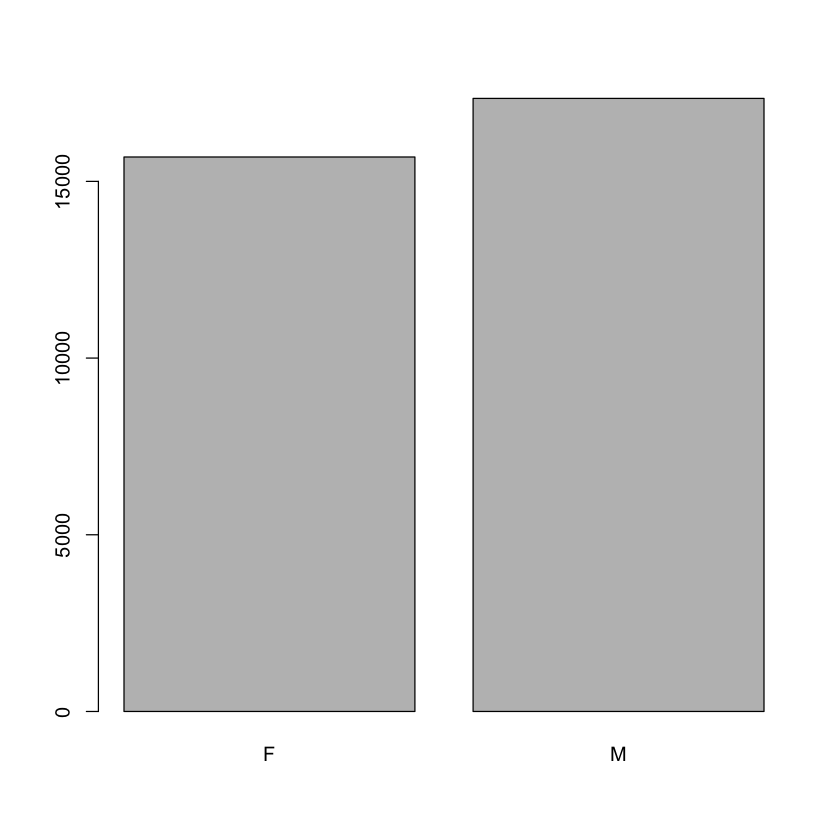

In [28]:
## bar plot of the number of females and males captured during the experiment:
plot(surveys$sex)

However, as we saw when we used `summary(surveys$sex)`, there are about 1700 individuals for which the sex information hasn’t been recorded. To show them in the plot, we can turn the missing values into a factor level with the `addNA()` function. We will also have to give the new factor level a label. We are going to work with a copy of the sex column, so we’re not modifying the working copy of the data frame:

In [29]:
sex <- surveys$sex
levels(sex)

[1] "F" "M"

In [30]:
sex <- addNA(sex)
levels(sex)

[1] "F" "M" NA

In [33]:
head(sex, n = 30)

[1] M    M    <NA> <NA> <NA> <NA> <NA> <NA> M    <NA> <NA> M    M    M    M   
[16] <NA> M    M    M    M    F    F    F    F    F    F    F    M    M    M   
Levels: F M <NA>

In [34]:
# Or you can change the name of "NA" to "undetermined"
levels(sex)[3] <- "undetermined"
levels(sex)

[1] "F"            "M"            "undetermined"

In [35]:
head(sex)

[1] M            M            undetermined undetermined undetermined
[6] undetermined
Levels: F M undetermined

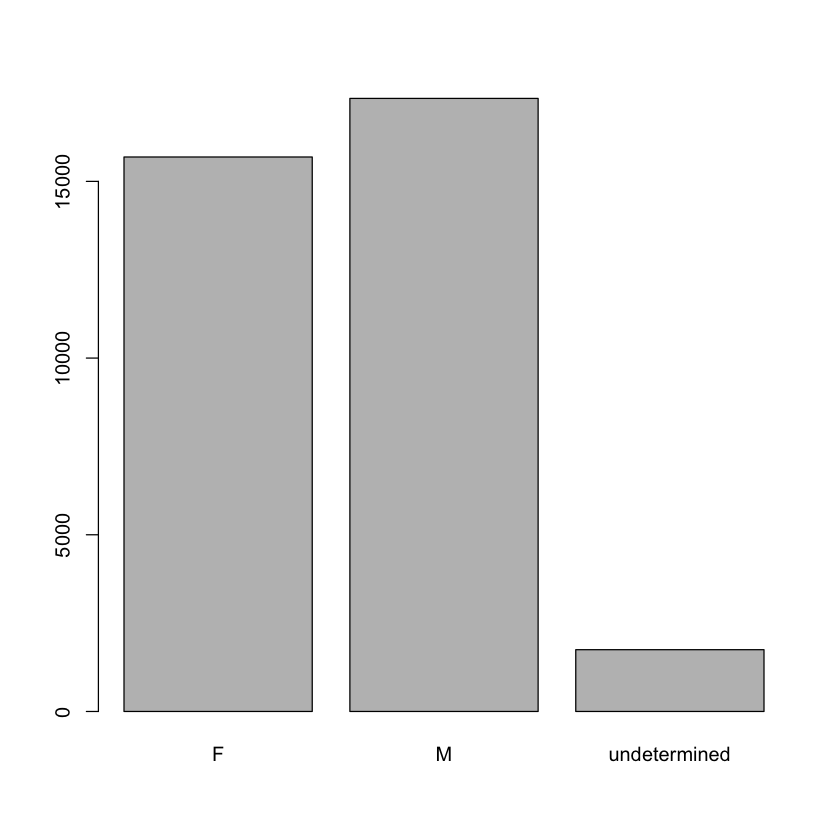

In [37]:
# And then, you can plot the data
plot(sex)

### Challenge
1. Rename `“F”` and `“M”` to `“female”` and `“male”` respectively.
2. Now that we have renamed the factor level to `“undetermined”`, can you recreate the barplot such that `“undetermined”` is first (before `“female”`)?

# 4. Formatting date
A common issue that new (and experienced!) R users have is converting date and time information into a variable that is suitable for analyses. One way to store date information is to store each component of the date in a separate column. Using `str()`, we can confirm that our data frame does indeed have a separate column for day, month, and year, and that each of these columns contains integer values.

In [38]:
str(surveys)

spc_tbl_ [34,786 × 13] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ record_id      : num [1:34786] 1 72 224 266 349 363 435 506 588 661 ...
 $ month          : num [1:34786] 7 8 9 10 11 11 12 1 2 3 ...
 $ day            : num [1:34786] 16 19 13 16 12 12 10 8 18 11 ...
 $ year           : num [1:34786] 1977 1977 1977 1977 1977 ...
 $ plot_id        : num [1:34786] 2 2 2 2 2 2 2 2 2 2 ...
 $ species_id     : chr [1:34786] "NL" "NL" "NL" "NL" ...
 $ sex            : Factor w/ 2 levels "F","M": 2 2 NA NA NA NA NA NA 2 NA ...
 $ hindfoot_length: num [1:34786] 32 31 NA NA NA NA NA NA NA NA ...
 $ weight         : num [1:34786] NA NA NA NA NA NA NA NA 218 NA ...
 $ genus          : chr [1:34786] "Neotoma" "Neotoma" "Neotoma" "Neotoma" ...
 $ species        : chr [1:34786] "albigula" "albigula" "albigula" "albigula" ...
 $ taxa           : chr [1:34786] "Rodent" "Rodent" "Rodent" "Rodent" ...
 $ plot_type      : chr [1:34786] "Control" "Control" "Control" "Control" ...
 - attr(*, "spec")=
  .. c

We are going to use the `ymd()` function from the package **lubridate** (which belongs to the tidyverse; learn more [here](https://www.tidyverse.org/)). lubridate gets installed as part as the tidyverse installation. When you load the tidyverse (`library(tidyverse)`), the core packages (the packages used in most data analyses) get loaded. lubridate however does not belong to the core tidyverse (<span style="color:darkred">**NOTE**: I loaded tidyverse on 23 Jan 2024 and found lubridate was included in the core tidyverse packages.</span> You may check in your own environment), so you have to load it explicitly with `library(lubridate)`.

Start by loading the required package:

In [39]:
library(lubridate)

The lubridate package has many useful functions for working with dates. These can help you extract dates from different string representations, convert between timezones, calculate time differences and more. You can find an overview of them in the [lubridate cheat sheet](https://raw.githubusercontent.com/rstudio/cheatsheets/main/lubridate.pdf).

Here we will use the function `ymd()`, which takes a vector representing year, month, and day, and converts it to a **Date** vector. **Date** is a class of data recognized by R as being a date and can be manipulated as such. The argument that the function requires is flexible, but, as a best practice, is a character vector formatted as “YYYY-MM-DD”.

Let’s create a date object and inspect the structure:

In [40]:
my_date <- ymd("2015-01-01")
str(my_date)

 Date[1:1], format: "2015-01-01"


Now let’s paste the year, month, and day separately - we get the same result:

In [41]:
# sep indicates the character to use to separate each component
my_date <- ymd(paste("2015", "1", "1", sep = "-")) 
str(my_date)

 Date[1:1], format: "2015-01-01"


Now we apply this function to the surveys dataset. Create a character vector from the year, month, and day columns of surveys using `paste()`:

In [ ]:
ymd(paste(surveys$year, surveys$month, surveys$day, sep = "-"))

There is a warning telling us that some dates could not be parsed (= understood) by the `ymd()` function. For these dates, the function has returned `NA`, which means they are treated as missing values. We will deal with this problem later, but first we add the resulting Date vector to the surveys data frame as a new column called date:

In [44]:
surveys$date <- ymd(paste(surveys$year, surveys$month, surveys$day, sep = "-"))
str(surveys) # notice the new column, with 'date' as the class

Warning message:
“ 129 failed to parse.”


spc_tbl_ [34,786 × 14] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ record_id      : num [1:34786] 1 72 224 266 349 363 435 506 588 661 ...
 $ month          : num [1:34786] 7 8 9 10 11 11 12 1 2 3 ...
 $ day            : num [1:34786] 16 19 13 16 12 12 10 8 18 11 ...
 $ year           : num [1:34786] 1977 1977 1977 1977 1977 ...
 $ plot_id        : num [1:34786] 2 2 2 2 2 2 2 2 2 2 ...
 $ species_id     : chr [1:34786] "NL" "NL" "NL" "NL" ...
 $ sex            : Factor w/ 2 levels "F","M": 2 2 NA NA NA NA NA NA 2 NA ...
 $ hindfoot_length: num [1:34786] 32 31 NA NA NA NA NA NA NA NA ...
 $ weight         : num [1:34786] NA NA NA NA NA NA NA NA 218 NA ...
 $ genus          : chr [1:34786] "Neotoma" "Neotoma" "Neotoma" "Neotoma" ...
 $ species        : chr [1:34786] "albigula" "albigula" "albigula" "albigula" ...
 $ taxa           : chr [1:34786] "Rodent" "Rodent" "Rodent" "Rodent" ...
 $ plot_type      : chr [1:34786] "Control" "Control" "Control" "Control" ...
 $ date           : Date[1

Let’s make sure everything worked correctly. One way to inspect the new column is to use `summary()`:

In [45]:
summary(surveys$date)

Min.      1st Qu.       Median         Mean      3rd Qu.         Max. 
"1977-07-16" "1984-03-12" "1990-07-22" "1990-12-15" "1997-07-29" "2002-12-31" 
        NA's 
       "129"

Let’s investigate why some dates could not be parsed.

We can use the functions we saw previously to deal with missing data to identify the rows in our data frame that are failing. If we combine them with what we learned about subsetting data frames earlier, we can extract the columns “year,”month”, “day” from the records that have `NA` in our new column date. We will also use `head()` so we don’t clutter the output:

In [48]:
missing_dates <- surveys[is.na(surveys$date), c("year", "month", "day")]
head(missing_dates)

year,month,day
<dbl>,<dbl>,<dbl>
2000,9,31
2000,4,31
2000,4,31
2000,4,31
2000,4,31
2000,9,31


Why did these dates fail to parse? If you had to use these data for your analyses, how would you deal with this situation?

The answer is because the dates provided as input for the `ymd()` function do not actually exist. If we refer to the output we got above, September and April only have 30 days, not 31 days as it is specified in our dataset.

There are several ways you could deal with situation:
- If you have access to the raw data (e.g., field sheets) or supporting information (e.g., field trip reports/logs), check them and ensure the electronic database matches the information in the original data source.
- If you are able to contact the person responsible for collecting the data, you could refer to them and ask for clarification.
- You could also check the rest of the dataset for clues about the correct value for the erroneous dates.
- If your project has guidelines on how to correct this sort of errors, refer to them and apply any recommendations.
- If it is not possible to ascertain the correct value for these observations, you may want to leave them as missing data.


Regardless of the option you choose, it is important that you document the error and the corrections (if any) that you apply to your data.

### Challenge
- Please make a vector that contains multiple types (e.g., "numeric" and "character") and check what happens if you apply `class()` or `typeof()` to the vector.